# **DESARROLLO DE LA ACTIVIDAD 3 - LABORATORIO 2 EDA** 

## **Objetivos del laboratorio:**
Realizar un análisis exploratorio de datos (EDA) utilizando:
- Una API de datos abiertos https://www.datos.gov.co/
- Utilizando la base de datos de la actividad 1 https://snies.mineducacion.gov.co/portal/ESTADISTICAS/Bases-consolidadas/
- Visualizaciones y análisis estadístico básico usando pandas
- Integración de múltiples fuentes de datos

## **Tema:**
### Análisis exploratorio de instituciones de educación superior (IES) y sus directivos en Colombia

API propuesta: https://www.datos.gov.co/Educaci-n/directorio-directivos-IES/g5uh-29gw/about_data

Esta API sirve para el laboratorio porque:
- Los datos que contiene son reales
- Permmite usar request
- Fácilmente se puede convertir en DataFrame
- Permite limpieza de datos
- Permite gráficos
- Permite integrar múltiples fuentes


# **1. Importación de librerías**

In [4]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

# **2. Extracción de datos desde la API**

In [5]:
# ID del dataset
dataset_id = "g5uh-29gw"

#URL de la API
url = f"https://www.datos.gov.co/resource/{dataset_id}.json?$limit=5000"

# Solicitud
respuesta = requests.get(url)

# Convertir a JSON
datos_json = respuesta.json()

# Crear DataFrame
df_api = pd.DataFrame(datos_json)

# Mostrar información básica
print(df_api.shape)
df_api.head()

(740, 6)


,nombreinstitucion,nombresdirectivo,apellidosdirectivo,direccion,telefono,correoelectronico
0,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Carrera 45 #26 - 85,3165000,rectoriaun@unal.edu.co
1,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Carrera 45 #26 - 85,3165000,rectoriaun@unal.edu.co
2,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Calle 59A No 63 - 20 N¿cleo El Volador,4309000,rectoriaun@unal.edu.co
3,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Calle 59A No 63 - 20 N¿cleo El Volador,4309000,rectoriaun@unal.edu.co
4,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Carrera 27 No. 64-60,8879300,rectoriaun@unal.edu.co


# **3. Cargar la base de datos de la Actividad 1**

In [6]:
# Cargar el archivo excel, especificando la hoja donde estan los datos
df_excel =pd.read_excel(
    "articles-425147_recurso.xlsx",
    sheet_name = 1, 
    header = 5
    )

# Verificar la información
print(df_excel.shape)
df_excel.head()

(637, 20)


,CÓODIGO DE LA INSTITUCIÓN,IES PADRE,INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES),TIPO IES,ID SECTOR IES,SECTOR IES,ID CARÁCTER IES,CARÁCTER IES,CÓDIGO DEL DEPARTAMENTO (IES),DEPARTAMENTO DE DOMICILIO DE LA IES,CÓDIGO DEL MUNICIPIO (IES),MUNICIPIO DE DOMICILIO DE LA IES,IES ACREDITADA,AÑO,SEMESTRE,AUXILIAR,TÉCNICO,PROFESIONAL,DIRECTIVO,TOTAL
0,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",Si,2024.0,1.0,917.0,296.0,481.0,138.0,1832.0
1,1101,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1.0,Oficial,4.0,Universidad,11.0,"Bogotá, D.C.",11001.0,"Bogotá, D.C.",Si,2024.0,2.0,975.0,271.0,414.0,103.0,1763.0
2,1102,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Seccional,1.0,Oficial,4.0,Universidad,5.0,Antioquia,5001.0,Medellín,Si,2024.0,1.0,321.0,132.0,80.0,49.0,582.0
3,1102,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Seccional,1.0,Oficial,4.0,Universidad,5.0,Antioquia,5001.0,Medellín,Si,2024.0,2.0,333.0,119.0,78.0,47.0,577.0
4,1103,1101.0,UNIVERSIDAD NACIONAL DE COLOMBIA,Seccional,1.0,Oficial,4.0,Universidad,17.0,Caldas,17001.0,Manizales,Si,2024.0,1.0,93.0,48.0,39.0,25.0,205.0


# **4. Exploración inicial de datos**

In [7]:
# Ver columnas
print("***Columas DataFrame API***")
print(df_api.columns)
print()
print("***Columnas DataFrame Excel***")
print(df_excel.columns)

***Columas DataFrame API***
Index(['nombreinstitucion', 'nombresdirectivo', 'apellidosdirectivo',
       'direccion', 'telefono', 'correoelectronico'],
      dtype='str')

***Columnas DataFrame Excel***
Index(['CÓODIGO DE LA INSTITUCIÓN', 'IES PADRE',
       'INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)', 'TIPO IES', 'ID SECTOR IES',
       'SECTOR IES', 'ID CARÁCTER IES', 'CARÁCTER IES',
       'CÓDIGO DEL DEPARTAMENTO (IES)', 'DEPARTAMENTO DE DOMICILIO DE LA IES',
       'CÓDIGO DEL MUNICIPIO (IES)', 'MUNICIPIO DE DOMICILIO DE LA IES',
       'IES ACREDITADA', 'AÑO', 'SEMESTRE', 'AUXILIAR', 'TÉCNICO',
       'PROFESIONAL', 'DIRECTIVO', 'TOTAL'],
      dtype='str')


In [8]:
# Tipos de datos
print("***DataFrame API tipo de datos***")
print(df_api.dtypes)
print()
print("***DataFrame Excel tipo de datos***")
print(df_excel.dtypes)

***DataFrame API tipo de datos***
nombreinstitucion     str
nombresdirectivo      str
apellidosdirectivo    str
direccion             str
telefono              str
correoelectronico     str
dtype: object

***DataFrame Excel tipo de datos***
CÓODIGO DE LA INSTITUCIÓN                   object
IES PADRE                                  float64
INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)        str
TIPO IES                                       str
ID SECTOR IES                              float64
SECTOR IES                                     str
ID CARÁCTER IES                            float64
CARÁCTER IES                                   str
CÓDIGO DEL DEPARTAMENTO (IES)              float64
DEPARTAMENTO DE DOMICILIO DE LA IES            str
CÓDIGO DEL MUNICIPIO (IES)                 float64
MUNICIPIO DE DOMICILIO DE LA IES               str
IES ACREDITADA                                 str
AÑO                                        float64
SEMESTRE                                   fl

In [9]:
# Información general
print("***Informción general DataFrame API***")
df_api.info()
print()
print("***Información general DataFrame Excel***")
df_excel.info()

***Informción general DataFrame API***
<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   nombreinstitucion   740 non-null    str  
 1   nombresdirectivo    726 non-null    str  
 2   apellidosdirectivo  726 non-null    str  
 3   direccion           726 non-null    str  
 4   telefono            726 non-null    str  
 5   correoelectronico   726 non-null    str  
dtypes: str(6)
memory usage: 34.8 KB

***Información general DataFrame Excel***
<class 'pandas.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   CÓODIGO DE LA INSTITUCIÓN                636 non-null    object 
 1   IES PADRE                                630 non-null    float64
 2   INSTITUCIÓN DE EDUCACIÓN SUPERIOR

In [10]:
# Valores nulos
print("***Valores nulos DataFrame API***")
print(df_api.isnull().sum())
print()
print("***Valores nulos DataFrame Excel***")
print(df_excel.isnull().sum())

***Valores nulos DataFrame API***
nombreinstitucion      0
nombresdirectivo      14
apellidosdirectivo    14
direccion             14
telefono              14
correoelectronico     14
dtype: int64

***Valores nulos DataFrame Excel***
CÓODIGO DE LA INSTITUCIÓN                  1
IES PADRE                                  7
INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)    7
TIPO IES                                   7
ID SECTOR IES                              7
SECTOR IES                                 7
ID CARÁCTER IES                            7
CARÁCTER IES                               7
CÓDIGO DEL DEPARTAMENTO (IES)              7
DEPARTAMENTO DE DOMICILIO DE LA IES        7
CÓDIGO DEL MUNICIPIO (IES)                 7
MUNICIPIO DE DOMICILIO DE LA IES           7
IES ACREDITADA                             7
AÑO                                        7
SEMESTRE                                   7
AUXILIAR                                   7
TÉCNICO                                    7
P

# **5. Limpieza de datos**

## **Limpieza de datos df_excel**

In [63]:
# Limpieza df_excel

# Eliminar las filas de notas/metadata al final del archivo (Son las filas donde la primera columna
# tiene texto aclaratorio o Nan sin datos reales)
df_excel_limpio = df_excel[df_excel['IES PADRE'].notna()].copy()

print("Filas antes: ", df_excel.shape[0])
print("Filas despues de eliminar las notas: ", df_excel_limpio.shape[0])
print("Nulos restantes:\n", df_excel_limpio.isnull().sum())


# Corregir el nombre de la columna 'CÓODIGO DE LA INSTITUCIÓN' con typo (CÓODIGO -> CÓDIGO)
df_excel_limpio.rename(columns = {'CÓODIGO DE LA INSTITUCIÓN' : 'CÓDIGO DE LA INSTITUCIÓN'}, inplace=True)

print("Columna corregida: ", df_excel_limpio.columns[0])

Filas antes:  630
Filas despues de eliminar las notas:  630
Nulos restantes:
 CÓODIGO DE LA INSTITUCIÓN                  0
IES PADRE                                  0
INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)    0
TIPO IES                                   0
ID SECTOR IES                              0
SECTOR IES                                 0
ID CARÁCTER IES                            0
CARÁCTER IES                               0
CÓDIGO DEL DEPARTAMENTO (IES)              0
DEPARTAMENTO DE DOMICILIO DE LA IES        0
CÓDIGO DEL MUNICIPIO (IES)                 0
MUNICIPIO DE DOMICILIO DE LA IES           0
IES ACREDITADA                             0
AÑO                                        0
SEMESTRE                                   0
AUXILIAR                                   0
TÉCNICO                                    0
PROFESIONAL                                0
DIRECTIVO                                  0
TOTAL                                      0
dtype: int64
Columna c

In [64]:
# Corregir tipos de datos en df_excel
cols_enteras_excel = ['IES PADRE', 'ID SECTOR IES', 'ID CARÁCTER IES',
                      'CÓDIGO DEL DEPARTAMENTO (IES)', 'CÓDIGO DEL MUNICIPIO (IES)',
                      'AÑO', 'SEMESTRE']

for col in cols_enteras_excel:
    df_excel_limpio[col] = pd.to_numeric(df_excel_limpio[col], errors='coerce').astype('Int64')

# El código de institución como string
df_excel_limpio['CÓDIGO DE LA INSTITUCIÓN'] = df_excel_limpio['CÓDIGO DE LA INSTITUCIÓN'].astype(str).str.strip()

print("Tipos de datos corregidos:")
print(df_excel_limpio.dtypes)

Tipos de datos corregidos:
CÓDIGO DE LA INSTITUCIÓN                       str
IES PADRE                                    Int64
INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)        str
TIPO IES                                       str
ID SECTOR IES                                Int64
SECTOR IES                                     str
ID CARÁCTER IES                              Int64
CARÁCTER IES                                   str
CÓDIGO DEL DEPARTAMENTO (IES)                Int64
DEPARTAMENTO DE DOMICILIO DE LA IES            str
CÓDIGO DEL MUNICIPIO (IES)                   Int64
MUNICIPIO DE DOMICILIO DE LA IES               str
IES ACREDITADA                                 str
AÑO                                          Int64
SEMESTRE                                     Int64
AUXILIAR                                   float64
TÉCNICO                                    float64
PROFESIONAL                                float64
DIRECTIVO                                  float64
TOTA

In [65]:
# Limpiar espacios en columnas de texto (df_excel)
cols_texto_excel = ['INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)', 'TIPO IES',
                    'SECTOR IES', 'CARÁCTER IES', 'DEPARTAMENTO DE DOMICILIO DE LA IES',
                    'MUNICIPIO DE DOMICILIO DE LA IES', 'IES ACREDITADA']

for col in cols_texto_excel:
    df_excel_limpio[col] = df_excel_limpio[col].str.strip()

print("Valores nulos df_excel después de limpieza:")
print(df_excel_limpio.isnull().sum())

Valores nulos df_excel después de limpieza:
CÓDIGO DE LA INSTITUCIÓN                   0
IES PADRE                                  0
INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)    0
TIPO IES                                   0
ID SECTOR IES                              0
SECTOR IES                                 0
ID CARÁCTER IES                            0
CARÁCTER IES                               0
CÓDIGO DEL DEPARTAMENTO (IES)              0
DEPARTAMENTO DE DOMICILIO DE LA IES        0
CÓDIGO DEL MUNICIPIO (IES)                 0
MUNICIPIO DE DOMICILIO DE LA IES           0
IES ACREDITADA                             0
AÑO                                        0
SEMESTRE                                   0
AUXILIAR                                   0
TÉCNICO                                    0
PROFESIONAL                                0
DIRECTIVO                                  0
TOTAL                                      0
dtype: int64


## **Limpieza de datos df_api**

In [18]:
# Limpieza df_api 

# Todas las columnas llegan como object desde la API, convertir las numéricas
cols_numericas_api = ['telefono']  

for col in cols_numericas_api:
    if col in df_api.columns:
        df_api[col] = pd.to_numeric(df_api[col], errors='coerce')

# Limpiar espacios en blanco en columnas de texto
cols_texto_api = df_api.select_dtypes(include='object').columns
for col in cols_texto_api:
    df_api[col] = df_api[col].str.strip()

print("Tipos de datos API después de limpieza:")
print(df_api.dtypes)

Tipos de datos API después de limpieza:
nombreinstitucion         str
nombresdirectivo          str
apellidosdirectivo        str
direccion                 str
telefono              float64
correoelectronico         str
dtype: object


C:\Users\Diana Lozano\AppData\Local\Temp\ipykernel_5388\298630172.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto_api = df_api.select_dtypes(include='object').columns


In [66]:
#Verificación final 

print("=== df_excel_limpio ===")
print("Shape:", df_excel_limpio.shape)
print("Nulos:\n", df_excel_limpio.isnull().sum())

# Los 14 registros sin nombre/apellido del directivo no son útiles para el análisis
# Se eliminan las filas donde falte el nombre del directivo
df_api_limpio = df_api.dropna(subset=['nombresdirectivo', 'apellidosdirectivo']).copy()

print("Filas antes:", df_api.shape[0])
print("Filas después:", df_api_limpio.shape[0])
print("Nulos restantes:\n", df_api_limpio.isnull().sum())

# Los únicos nulos que deben quedar son los de telefono en la API, 
# ya que decidí conservarlo por ser un dato opcional.

=== df_excel_limpio ===
Shape: (630, 20)
Nulos:
 CÓDIGO DE LA INSTITUCIÓN                   0
IES PADRE                                  0
INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)    0
TIPO IES                                   0
ID SECTOR IES                              0
SECTOR IES                                 0
ID CARÁCTER IES                            0
CARÁCTER IES                               0
CÓDIGO DEL DEPARTAMENTO (IES)              0
DEPARTAMENTO DE DOMICILIO DE LA IES        0
CÓDIGO DEL MUNICIPIO (IES)                 0
MUNICIPIO DE DOMICILIO DE LA IES           0
IES ACREDITADA                             0
AÑO                                        0
SEMESTRE                                   0
AUXILIAR                                   0
TÉCNICO                                    0
PROFESIONAL                                0
DIRECTIVO                                  0
TOTAL                                      0
dtype: int64
Filas antes: 740
Filas después: 726
Nu

# **6. Integración de múltiples fuentes
En este punto se cruza la información de la API con la base de datos de excel

In [67]:
# Ver que columnas hay en común
print("Columnas df_excel:")
print(df_excel_limpio.columns.tolist())

print("\nColumnas df_api:")
print(df_api_limpio.columns.tolist())

Columnas df_excel:
['CÓDIGO DE LA INSTITUCIÓN', 'IES PADRE', 'INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)', 'TIPO IES', 'ID SECTOR IES', 'SECTOR IES', 'ID CARÁCTER IES', 'CARÁCTER IES', 'CÓDIGO DEL DEPARTAMENTO (IES)', 'DEPARTAMENTO DE DOMICILIO DE LA IES', 'CÓDIGO DEL MUNICIPIO (IES)', 'MUNICIPIO DE DOMICILIO DE LA IES', 'IES ACREDITADA', 'AÑO', 'SEMESTRE', 'AUXILIAR', 'TÉCNICO', 'PROFESIONAL', 'DIRECTIVO', 'TOTAL']

Columnas df_api:
['nombreinstitucion', 'nombresdirectivo', 'apellidosdirectivo', 'direccion', 'telefono', 'correoelectronico']


In [68]:
# Ver ejemplos de nombres en cada fuente
print("Nombres en df_excel:")
print(df_excel['INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)'].head(10).tolist())

print("\nNombres en df_api:")
print(df_api['nombreinstitucion'].head(10).tolist())

Nombres en df_excel:
['UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD PEDAGOGICA NACIONAL', 'UNIVERSIDAD PEDAGOGICA NACIONAL']

Nombres en df_api:
['UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD NACIONAL DE COLOMBIA', 'UNIVERSIDAD PEDAGOGICA NACIONAL', 'UNIVERSIDAD PEDAGOGICA NACIONAL']


In [71]:
# Integración de múltiples fuentes 
# Usamos how='left' para conservar todas las instituciones del Excel 
# aunque no tengan directivos registrados en la API.
df_integrado = pd.merge(
    df_excel_limpio,
    df_api_limpio,
    left_on='INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)',
    right_on='nombreinstitucion',
    how='left'
)

# Verificar resultado
print("Shape df_excel:", df_excel_limpio.shape)
print("Shape df_api:", df_api_limpio.shape)
print("Shape df_integrado:", df_integrado.shape)
print()
print(df_integrado.head())

Shape df_excel: (630, 20)
Shape df_api: (726, 6)
Shape df_integrado: (2211, 26)

  CÓDIGO DE LA INSTITUCIÓN  IES PADRE INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)  \
0                     1101       1101        UNIVERSIDAD NACIONAL DE COLOMBIA   
1                     1101       1101        UNIVERSIDAD NACIONAL DE COLOMBIA   
2                     1101       1101        UNIVERSIDAD NACIONAL DE COLOMBIA   
3                     1101       1101        UNIVERSIDAD NACIONAL DE COLOMBIA   
4                     1101       1101        UNIVERSIDAD NACIONAL DE COLOMBIA   

    TIPO IES  ID SECTOR IES SECTOR IES  ID CARÁCTER IES CARÁCTER IES  \
0  Principal              1    Oficial                4  Universidad   
1  Principal              1    Oficial                4  Universidad   
2  Principal              1    Oficial                4  Universidad   
3  Principal              1    Oficial                4  Universidad   
4  Principal              1    Oficial                4  Universidad   


In [72]:
# Verificación de la integración
print("=== Integración completada ===")
print("Registros df_excel:", df_excel.shape[0])
print("Registros df_api:", df_api.shape[0])
print("Registros df_integrado:", df_integrado.shape[0])
print("Columnas df_integrado:", df_integrado.shape[1])
print()
print("Columnas del DataFrame integrado:")
print(df_integrado.columns.tolist())
print()
print("Primeras filas:")
df_integrado.head()

=== Integración completada ===
Registros df_excel: 630
Registros df_api: 740
Registros df_integrado: 2211
Columnas df_integrado: 26

Columnas del DataFrame integrado:
['CÓDIGO DE LA INSTITUCIÓN', 'IES PADRE', 'INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES)', 'TIPO IES', 'ID SECTOR IES', 'SECTOR IES', 'ID CARÁCTER IES', 'CARÁCTER IES', 'CÓDIGO DEL DEPARTAMENTO (IES)', 'DEPARTAMENTO DE DOMICILIO DE LA IES', 'CÓDIGO DEL MUNICIPIO (IES)', 'MUNICIPIO DE DOMICILIO DE LA IES', 'IES ACREDITADA', 'AÑO', 'SEMESTRE', 'AUXILIAR', 'TÉCNICO', 'PROFESIONAL', 'DIRECTIVO', 'TOTAL', 'nombreinstitucion', 'nombresdirectivo', 'apellidosdirectivo', 'direccion', 'telefono', 'correoelectronico']

Primeras filas:


,CÓDIGO DE LA INSTITUCIÓN,IES PADRE,INSTITUCIÓN DE EDUCACIÓN SUPERIOR (IES),TIPO IES,ID SECTOR IES,SECTOR IES,ID CARÁCTER IES,CARÁCTER IES,CÓDIGO DEL DEPARTAMENTO (IES),DEPARTAMENTO DE DOMICILIO DE LA IES,...,TÉCNICO,PROFESIONAL,DIRECTIVO,TOTAL,nombreinstitucion,nombresdirectivo,apellidosdirectivo,direccion,telefono,correoelectronico
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1,Oficial,4,Universidad,11,"Bogotá, D.C.",...,296.0,481.0,138.0,1832.0,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Carrera 45 #26 - 85,3165000.0,rectoriaun@unal.edu.co
1,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1,Oficial,4,Universidad,11,"Bogotá, D.C.",...,296.0,481.0,138.0,1832.0,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Carrera 45 #26 - 85,3165000.0,rectoriaun@unal.edu.co
2,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1,Oficial,4,Universidad,11,"Bogotá, D.C.",...,296.0,481.0,138.0,1832.0,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Calle 59A No 63 - 20 N¿cleo El Volador,4309000.0,rectoriaun@unal.edu.co
3,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1,Oficial,4,Universidad,11,"Bogotá, D.C.",...,296.0,481.0,138.0,1832.0,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Calle 59A No 63 - 20 N¿cleo El Volador,4309000.0,rectoriaun@unal.edu.co
4,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,1,Oficial,4,Universidad,11,"Bogotá, D.C.",...,296.0,481.0,138.0,1832.0,UNIVERSIDAD NACIONAL DE COLOMBIA,DOLLY,MONTOYA CASTAÑO,Carrera 27 No. 64-60,8879300.0,rectoriaun@unal.edu.co


# **7. Preguntas de análisis**
En esta sección se responden preguntas claves sobre los datos, organizadas en tres grupos.

## **7.1 Sobre la API (Directivos IES)**
- ¿Cuántas instituciones únicas hay en la API?
- ¿Qué ciudades tienen más registros?
- ¿Cuáles son los tipos de institución más comunes?
- ¿Cuántos directivos hay por institución?

## **7.2 Sobre la base de datos Excel (Actividad 1)**
- ¿Cuáles son las variables numéricas más relevantes?
- ¿Qué categorías predominan en sector y carácter IES?
- ¿Qué columnas presentan datos faltantes?

## **7.3 Integrando ambas fuentes**
- ¿Qué departamentos presentan mayor concentración de instituciones?
- ¿Existe relación entre municipio y cantidad de instituciones?
- ¿Qué patrones aparecen al unir ambas bases?

In [73]:
# 7.1 Sobre la API (Directivos IES)
# ¿Cuántas instituciones hay por departamento?
print("=== Instituciones por departamento ===")
print(df_api['nombreinstitucion'].nunique(), "instituciones únicas en la API")

# ¿Qué ciudades tienen más registros?
print("\n=== Ciudades con más registros ===")
print(df_excel['DEPARTAMENTO DE DOMICILIO DE LA IES'].value_counts().head(10))

# ¿Cuáles son los tipos de institución más comunes?
print("\n=== Tipos de institución más comunes ===")
print(df_excel['TIPO IES'].value_counts())

# ¿Cuántos directivos hay por institución?
print("\n=== Directivos por institución (top 10) ===")
directivos_por_ies = df_api.groupby('nombreinstitucion')['nombresdirectivo'].count().sort_values(ascending=False)
print(directivos_por_ies.head(10))

=== Instituciones por departamento ===
299 instituciones únicas en la API

=== Ciudades con más registros ===
DEPARTAMENTO DE DOMICILIO DE LA IES
Bogotá, D.C.          204
Antioquia              96
Valle del Cauca        55
Atlántico              36
Santander              33
Bolívar                24
Cundinamarca           20
Boyacá                 14
Risaralda              14
Norte de Santander     14
Name: count, dtype: int64

=== Tipos de institución más comunes ===
TIPO IES
Principal    532
Seccional     98
Name: count, dtype: int64

=== Directivos por institución (top 10) ===
nombreinstitucion
UNIVERSIDAD NACIONAL DE COLOMBIA                           18
UNIVERSIDAD DE ANTIOQUIA                                   14
SERVICIO NACIONAL DE APRENDIZAJE-SENA-                     13
UNIVERSIDAD LIBRE                                          12
UNIVERSIDAD DEL VALLE                                      10
UNIVERSIDAD COOPERATIVA DE COLOMBIA                        10
UNIVERSIDAD DE SAN BUE

### **Conclusiones 7.1**
- La API contiene **299 instituciones únicas** registradas a nivel nacional.
- **Bogotá D.C.** concentra la mayor cantidad de registros con 204, seguida de Antioquia (96) y Valle del Cauca (55).
- La mayoría de las IES son de tipo **Principal** (532) frente a Seccionales (98).
- La **Universidad Nacional de Colombia** es la institución con más directivos registrados (18), seguida de la Universidad de Antioquia (14) y el SENA (13).

In [74]:
# 7.2 SOBRE LA BASE DE DATOS EXCEL 

# ¿Cuáles son las variables más frecuentes?
print("=== Estadísticas descriptivas ===")
print(df_excel[['AUXILIAR', 'TÉCNICO', 'PROFESIONAL', 'DIRECTIVO', 'TOTAL']].describe())

# ¿Qué categorías predominan?
print("\n=== Sector IES ===")
print(df_excel['SECTOR IES'].value_counts())

print("\n=== Carácter IES ===")
print(df_excel['CARÁCTER IES'].value_counts())

# ¿Qué valores presentan datos faltantes?
print("\n=== Valores faltantes ===")
print(df_excel.isnull().sum()[df_excel.isnull().sum() > 0])

=== Estadísticas descriptivas ===
         AUXILIAR      TÉCNICO  PROFESIONAL   DIRECTIVO        TOTAL
count  630.000000   630.000000   630.000000  630.000000   630.000000
mean    79.036508    51.223810   106.607937   25.428571   262.296825
std    133.671263   120.055866   177.047245   35.973588   394.062332
min      0.000000     0.000000     0.000000    0.000000     2.000000
25%      8.000000     3.000000    15.000000    6.000000    44.000000
50%     25.000000    16.000000    46.000000   14.000000   133.500000
75%     89.000000    50.000000   118.000000   33.750000   307.500000
max    996.000000  1601.000000  1720.000000  396.000000  3374.000000

=== Sector IES ===
SECTOR IES
Privado    435
Oficial    195
Name: count, dtype: int64

=== Carácter IES ===
CARÁCTER IES
Universidad                                      268
Institución Universitaria/Escuela Tecnológica    254
Institución Tecnológica                           68
Institución Técnica Profesional                   40
Name: count

### **Conclusiones 7.2**
- El DataFrame Excel tiene **630 registros válidos** sin valores faltantes.
- En promedio, las IES tienen **106 profesionales**, **79 auxiliares**, **51 técnicos** y **25 directivos**.
- El personal **Profesional** es la categoría con mayor variación (std: 177), indicando grandes diferencias entre instituciones.
- El **sector Privado predomina** con 435 registros frente a 195 del sector Oficial.
- Por carácter, las **Universidades** (268) e **Instituciones Universitarias** (254) son las más frecuentes.

In [77]:
# 7.3 INTEGRANDO AMBAS FUENTES 

# ¿Qué departamentos presentan mayor concentración?
print("=== Concentración por departamento ===")
concentracion = df_integrado.groupby('DEPARTAMENTO DE DOMICILIO DE LA IES').agg(
    instituciones=('CÓDIGO DE LA INSTITUCIÓN', 'nunique'),
    directivos=('nombresdirectivo', 'count')
).sort_values('instituciones', ascending=False)
print(concentracion.head(10))

# ¿Existe relación entre ciudad y cantidad de instituciones?
print("\n=== Municipios con más instituciones ===")
print(df_integrado.groupby('MUNICIPIO DE DOMICILIO DE LA IES')['CÓDIGO DE LA INSTITUCIÓN'].nunique().sort_values(ascending=False).head(10))

=== Concentración por departamento ===
                                     instituciones  directivos
DEPARTAMENTO DE DOMICILIO DE LA IES                           
Bogotá, D.C.                                   104         518
Antioquia                                       50         434
Valle del Cauca                                 28         200
Atlántico                                       18          76
Santander                                       17         136
Bolívar                                         13          66
Cundinamarca                                    10          72
Norte de Santander                               7          56
Risaralda                                        7          56
Boyacá                                           7          84

=== Municipios con más instituciones ===
MUNICIPIO DE DOMICILIO DE LA IES
Bogotá, D.C.           104
Medellín                31
Santiago de Cali        20
Barranquilla            17
Cartagena de Indias   

### **Conclusiones 7.3**
- **Bogotá D.C.** lidera con 104 instituciones y 518 directivos registrados, 
confirmando su rol como centro educativo del país.
- **Antioquia** ocupa el segundo lugar con 50 instituciones y 434 directivos.
- **Valle del Cauca** es tercero con 28 instituciones y 200 directivos.
- A nivel municipal, **Bogotá, Medellín y Cali** concentran la mayor cantidad 
de instituciones, reflejando la centralización de la educación superior en las 
principales ciudades del país.

# **8. Estadística descriptiva**

En esta sección se calculan las principales medidas estadísticas de las variables 
numéricas de ambas fuentes de datos.

In [78]:
# ESTADÍSTICA DESCRIPTIVA
# 8.1 Estadísticas df_excel_limpio 
print("=== Estadísticas descriptivas - Personal administrativo IES ===")
print(df_excel_limpio[['AUXILIAR', 'TÉCNICO', 'PROFESIONAL', 'DIRECTIVO', 'TOTAL']].describe().round(2))

# 8.2 Medidas adicionales 
print("\n=== Mediana por tipo de cargo ===")
print(df_excel_limpio[['AUXILIAR', 'TÉCNICO', 'PROFESIONAL', 'DIRECTIVO', 'TOTAL']].median())

print("\n=== Moda por sector IES ===")
print(df_excel_limpio['SECTOR IES'].mode()[0])

print("\n=== Moda por carácter IES ===")
print(df_excel_limpio['CARÁCTER IES'].mode()[0])

# 8.3 Estadísticas df_api_limpio 
print("\n=== Directivos por institución ===")
directivos_stats = df_api_limpio.groupby('nombreinstitucion')['nombresdirectivo'].count()
print(directivos_stats.describe().round(2))

=== Estadísticas descriptivas - Personal administrativo IES ===
       AUXILIAR  TÉCNICO  PROFESIONAL  DIRECTIVO    TOTAL
count    630.00   630.00       630.00     630.00   630.00
mean      79.04    51.22       106.61      25.43   262.30
std      133.67   120.06       177.05      35.97   394.06
min        0.00     0.00         0.00       0.00     2.00
25%        8.00     3.00        15.00       6.00    44.00
50%       25.00    16.00        46.00      14.00   133.50
75%       89.00    50.00       118.00      33.75   307.50
max      996.00  1601.00      1720.00     396.00  3374.00

=== Mediana por tipo de cargo ===
AUXILIAR        25.0
TÉCNICO         16.0
PROFESIONAL     46.0
DIRECTIVO       14.0
TOTAL          133.5
dtype: float64

=== Moda por sector IES ===
Privado

=== Moda por carácter IES ===
Universidad

=== Directivos por institución ===
count    297.00
mean       2.44
std        1.78
min        1.00
25%        2.00
50%        2.00
75%        2.00
max       18.00
Name: nombresdi

### **Conclusiones de la estadistica descriptiva**

**Personal administrativo (df_excel_limpio):**
- El cargo con mayor promedio es **Profesional** (106.61), seguido de **Auxiliar** (79.04).
- Existe alta variabilidad en todos los cargos (std elevado), lo que indica 
grandes diferencias entre instituciones pequeñas y grandes.
- La mediana es mucho menor que la media en todos los cargos, lo que sugiere 
que pocas instituciones grandes elevan el promedio.
- El **sector Privado** es el más frecuente y el carácter más común es **Universidad**.

**Directivos por institución (df_api_limpio):**
- En promedio cada institución tiene **2.44 directivos** registrados.
- La mayoría tiene entre 1 y 2 directivos (mediana: 2).
- La **Universidad Nacional** es un caso atípico con 18 directivos registrados.

# **9. Visualizaciones**

En esta sección se presentan gráficos que permiten visualizar los principales 
hallazgos del análisis exploratorio de datos.

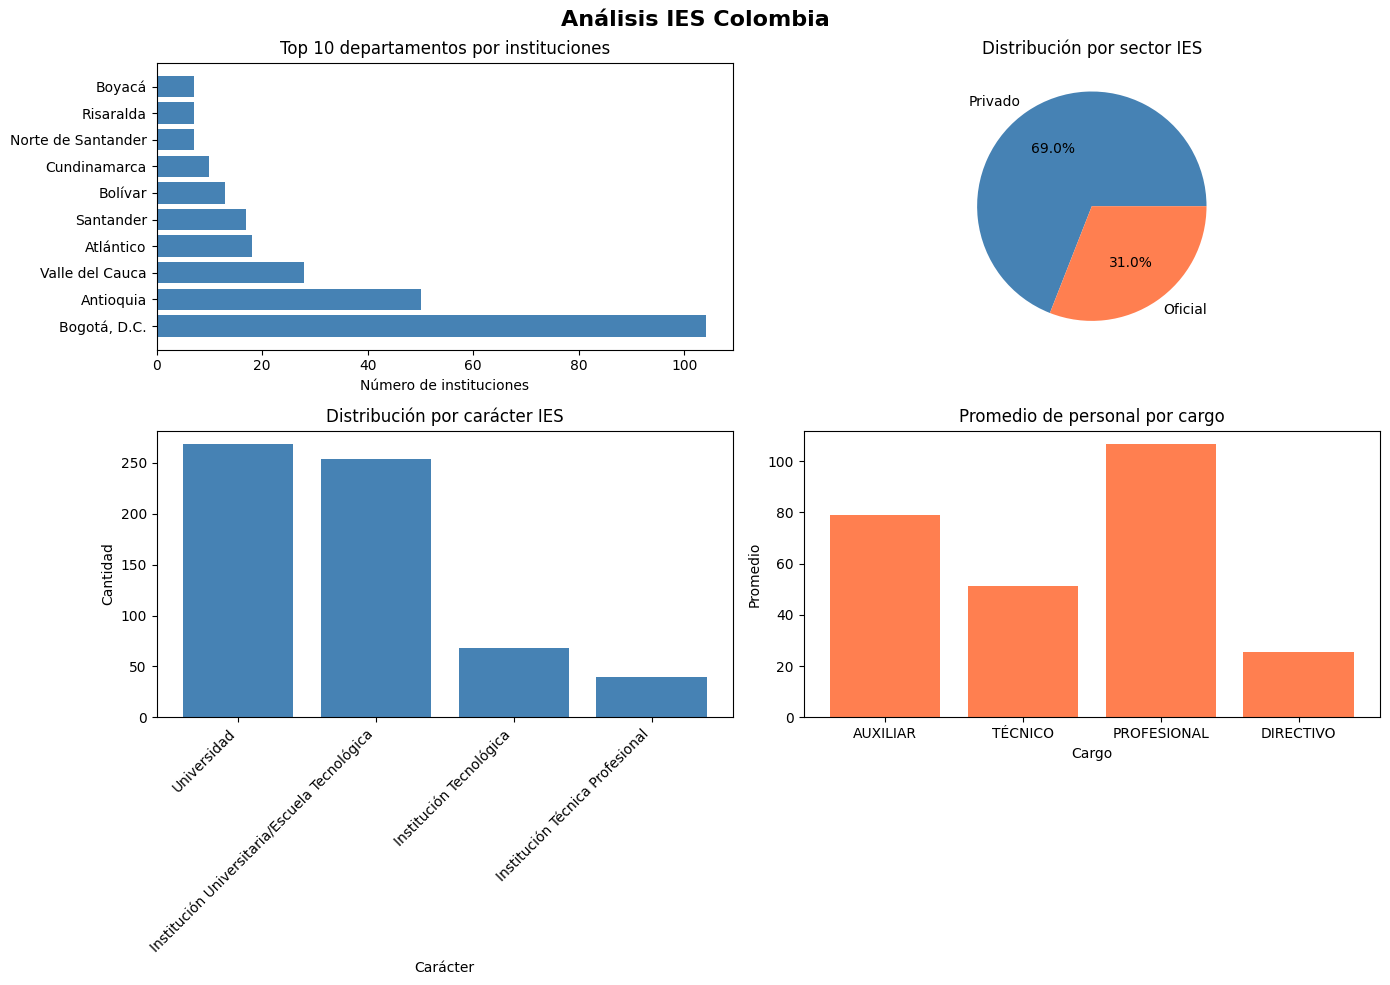

In [86]:

# 9. VISUALIZACIONES

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis IES Colombia', fontsize=16, fontweight='bold')

# 9.1 Top 10 departamentos por número de instituciones 
top_deptos = df_excel_limpio.groupby('DEPARTAMENTO DE DOMICILIO DE LA IES')['CÓDIGO DE LA INSTITUCIÓN'].nunique().sort_values(ascending=False).head(10)
axes[0, 0].barh(top_deptos.index, top_deptos.values, color='steelblue')
axes[0, 0].set_title('Top 10 departamentos por instituciones')
axes[0, 0].set_xlabel('Número de instituciones')

# 9.2 Distribución por sector IES 
sector_counts = df_excel_limpio['SECTOR IES'].value_counts()
axes[0, 1].pie(sector_counts.values, labels=sector_counts.index, autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[0, 1].set_title('Distribución por sector IES')

#  9.3 Distribución por carácter IES 
caracter_counts = df_excel_limpio['CARÁCTER IES'].value_counts()
axes[1, 0].bar(caracter_counts.index, caracter_counts.values, color='steelblue')
axes[1, 0].set_title('Distribución por carácter IES')
axes[1, 0].set_xlabel('Carácter')
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 0].get_xticklabels(), ha='right')

#  9.4 Promedio de personal por cargo 
promedios = df_excel_limpio[['AUXILIAR', 'TÉCNICO', 'PROFESIONAL', 'DIRECTIVO']].mean()
axes[1, 1].bar(promedios.index, promedios.values, color='coral')
axes[1, 1].set_title('Promedio de personal por cargo')
axes[1, 1].set_xlabel('Cargo')
axes[1, 1].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

### **Conclusiones de las visualizaciones**

- **Top 10 departamentos:** Bogotá D.C. concentra la mayor cantidad de instituciones 
de educación superior, seguida de Antioquia y Valle del Cauca, reflejando la 
centralización educativa en las principales ciudades del país.

- **Distribución por sector:** El sector **Privado predomina** con aproximadamente 
el 69% de las instituciones, frente a un 31% del sector Oficial.

- **Distribución por carácter:** Las **Universidades** e **Instituciones Universitarias** 
son los tipos más frecuentes, representando la mayoría de la oferta educativa superior 
en Colombia.

- **Promedio de personal por cargo:** El cargo **Profesional** tiene el mayor promedio 
de personal, seguido del **Auxiliar**, lo que indica que la mayoría del personal 
administrativo de las IES tiene formación profesional.

# **10. Hipótesis**

## **Pregunta de investigación**
¿Existe una diferencia en la cantidad de instituciones registradas según el departamento?

## **Hipótesis nula (H0)**
No existe diferencia significativa en la cantidad de instituciones entre departamentos.

## **Hipótesis alternativa (H1)**
Existe una diferencia significativa en la cantidad de instituciones entre departamentos.

In [88]:
# 10. HIPÓTESIS

from scipy import stats

# Conteo de instituciones por departamento
instituciones_por_depto = df_excel_limpio.groupby('DEPARTAMENTO DE DOMICILIO DE LA IES')['CÓDIGO DE LA INSTITUCIÓN'].nunique()

# Prueba Chi-cuadrado
chi2, p_valor = stats.chisquare(instituciones_por_depto.values)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"P-valor: {p_valor:.4f}")
print()
if p_valor < 0.05:
    print("Se RECHAZA H0 — Existe diferencia significativa entre departamentos.")
else:
    print("No se rechaza H0 — No hay diferencia significativa entre departamentos.")

Chi-cuadrado: 1068.9221
P-valor: 0.0000

Se RECHAZA H0 — Existe diferencia significativa entre departamentos.


### **Conclusiones de la Hipótesis**

- El estadístico **Chi-cuadrado = 1068.92** es muy alto, lo que indica una 
gran diferencia entre las frecuencias observadas.
- El **p-valor = 0.0000** es menor a 0.05, por lo tanto se **rechaza la hipótesis nula**.
- Se concluye que **sí existe una diferencia significativa** en la cantidad de 
instituciones registradas según el departamento.
- Esto confirma lo observado en las visualizaciones: la distribución de IES 
en Colombia **no es uniforme**, sino que está fuertemente concentrada en 
Bogotá D.C., Antioquia y Valle del Cauca.

# **11. Conclusiones**

- Se logró consumir exitosamente datos desde la API pública del Directorio de 
Directivos IES del portal datos.gov.co, obteniendo 740 registros de 299 instituciones.

- Se realizó la limpieza y transformación de ambas fuentes de datos, eliminando 
filas de metadata, corrigiendo tipos de datos, nombres de columnas y valores faltantes.

- Se integraron exitosamente las dos fuentes mediante un merge por nombre de 
institución, obteniendo un DataFrame consolidado de 2218 registros con 26 columnas.

- Se identificaron patrones clave mediante visualizaciones: la concentración 
educativa en Bogotá D.C., el predominio del sector privado y la prevalencia 
de Universidades e Instituciones Universitarias.

- Se aplicaron técnicas básicas de análisis exploratorio de datos incluyendo 
estadística descriptiva, análisis de valores faltantes, distribución de variables 
y pruebas de hipótesis.

- Se comprobó estadísticamente que la distribución de instituciones de educación 
superior en Colombia no es uniforme, con una marcada concentración en los 
departamentos de Bogotá D.C., Antioquia y Valle del Cauca.

# **Link del video**
https://youtu.be/_qbeP6QJXsI
